# OSM Point Features - Zaragoza

Downloads traffic signals, public transport stops and amenity POIs from OSM for Zaragoza,
counts them within a 50 m buffer of each street segment, normalizes by segment length
and exports `data/osm_points_features.csv`.
Roads loaded from `../layers/ZGZ_noise_streets.gpkg`.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

## Load roads

In [2]:
osm_roads = gpd.read_file("../layers/ZGZ_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25830
(14600, 11)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'geometry']
Number of street segments: 14600


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Traffic signals

In [3]:
signals = ox.features_from_place("Zaragoza, Spain", tags={"highway": "traffic_signals"})
signals = signals[signals.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(signals.crs)
print(signals.columns.tolist())

EPSG:25830
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'crossing', 'button_operated', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'source', 'direction', 'traffic_sign', 'fixme', 'crossing:island', 'crossing:markings']


In [4]:
print(f"Total signals: {len(signals)}")
if 'traffic_signals' in signals.columns:
    print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
    print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
    print("\nValue counts:")
    print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 1295
Non-null traffic_signals: 954
Null traffic_signals: 341

Value counts:
traffic_signals
signal                 939
NaN                    341
traffic_lights          10
pedestrian_crossing      3
blinker                  2
Name: count, dtype: int64


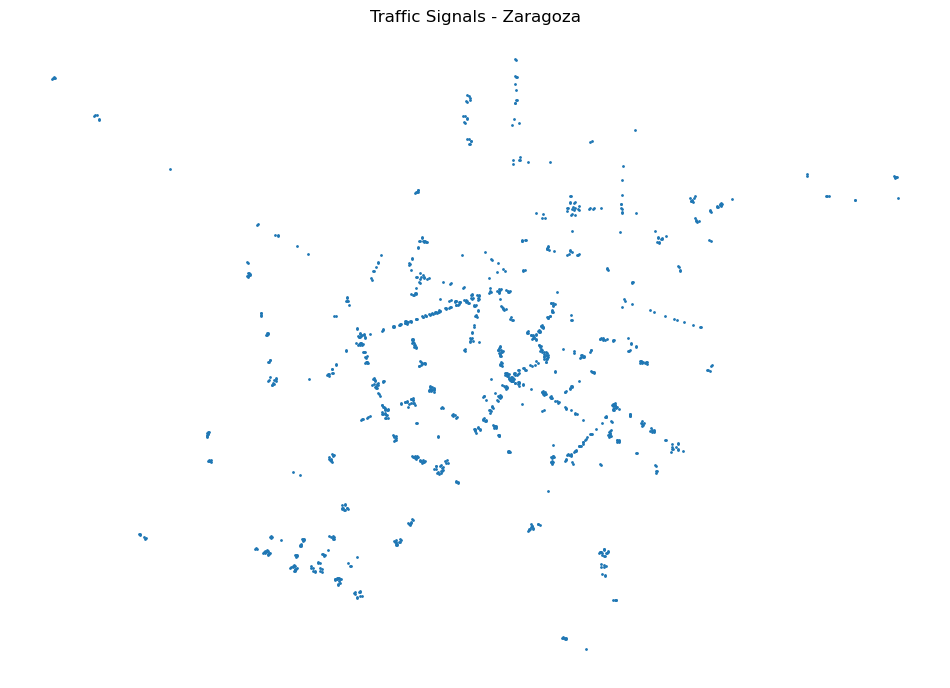

In [5]:
ax = signals.plot(markersize=1, figsize=(12, 12))
ax.set_title('Traffic Signals - Zaragoza')
ax.set_axis_off()

## Public transport stops

In [6]:
transport = ox.features_from_place(
    "Zaragoza, Spain",
    tags={"railway": ["station", "tram_stop", "subway_entrance"],
          "highway": "bus_stop"})
transport = transport[transport.geometry.type == 'Point'].to_crs(osm_roads.crs)
if 'railway' in transport.columns:
    transport['transport_type'] = transport['railway'].fillna(
        transport['highway'] if 'highway' in transport.columns else None
    )
elif 'highway' in transport.columns:
    transport['transport_type'] = transport['highway']
else:
    transport['transport_type'] = 'unknown'
print(transport.crs)
print(transport.columns.tolist())

EPSG:25830
['geometry', 'bench', 'bin', 'bus', 'highway', 'kerb', 'kerb:approach_aid', 'lit', 'mapillary', 'name', 'network', 'network:short', 'network:wikidata', 'operator', 'operator:wikidata', 'passenger_information_display', 'public_transport', 'ref', 'shelter', 'tactile_paving', 'wheelchair', 'network:guid', 'railway', 'tram', 'ref:AUZ', 'ref:CTAZ', 'owner', 'owner:wikidata', 'ref:EU:PLC', 'uic_ref', 'wikidata', 'panoramax', 'acoustic', 'covered', 'note', 'source', 'bus_lines', 'departures_board', 'passenger_information_display:AUZ', 'passenger_information_display:CTAZ', 'passenger_information_display:TPA', 'check_date', 'panoramax:0', 'old_name', 'passenger_information_display:speech_output', 'information', 'check_date:shelter', 'fixme', 'official_name', 'ref:ibnr', 'train', 'alt_name', 'ref:TRAZA', 'ref_name', 'wikimedia_commons', 'amenity', 'opening_hours', 'operator:type', 'network:wikipedia', 'type', 'location', 'noexit', 'ref:short', 'name:signed', 'addr:housenumber', 'addr:

In [7]:
print(f"Total transport points: {len(transport)}")
print(f"Non-null transport points: {transport['transport_type'].notna().sum()}")
print(f"Null transport points: {transport['transport_type'].isna().sum()}")
print("\nValue counts:")
print(transport['transport_type'].value_counts(dropna=False))

Total transport points: 1029
Non-null transport points: 1029
Null transport points: 0

Value counts:
transport_type
bus_stop     973
tram_stop     50
station        6
Name: count, dtype: int64


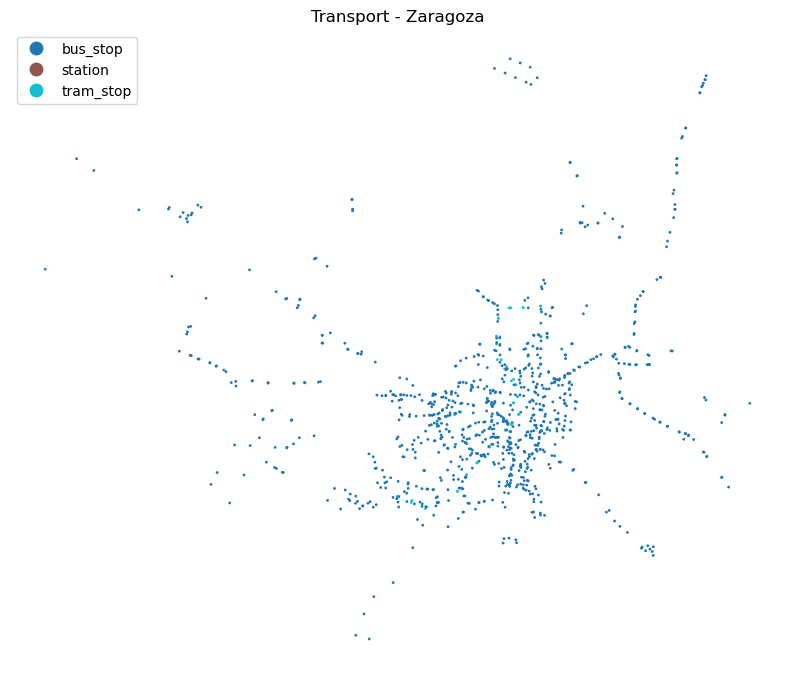

In [8]:
ax = transport.plot(column='transport_type', legend=True, markersize=1, figsize=(10, 10))
ax.set_title('Transport - Zaragoza')
ax.set_axis_off()

## POIs (amenities)

In [9]:
pois = ox.features_from_place(
    "Zaragoza, Spain",
    tags={"amenity": True}
)
pois = pois[pois.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(pois.crs)
print(pois.columns.tolist())

EPSG:25830
['geometry', 'addr:postcode', 'addr:street', 'amenity', 'healthcare', 'name', 'opening_hours', 'phone', 'source', 'atm', 'atm:network', 'brand', 'brand:wikidata', 'brand:wikipedia', 'check_date', 'operator', 'wheelchair', 'addr:housenumber', 'dispensing', 'note', 'toilets:wheelchair', 'denomination', 'religion', 'brand:ca', 'brand:es', 'name:ca', 'name:es', 'official_name', 'website', 'compressed_air', 'panoramax', 'access', 'layer', 'parking', 'contact:fax', 'contact:phone', 'education', 'ref:ayto_zaragoza', 'source:date', 'operator:type', 'operator:wikidata', 'outdoor_seating', 'cuisine', 'drive_through', 'takeaway', 'atm:operator', 'brand:-2024', 'brand:website', 'name:-2024', 'operator:-2024', 'fee', 'source:url', 'bicycle_rental', 'network', 'network:wikidata', 'ref', 'fuel:GTL_diesel', 'fuel:diesel', 'fuel:octane_95', 'fuel:octane_98', 'fuel:diesel_B', 'addr:milestone', 'brand:1992', 'official_name:1992', 'fuel:lpg', 'operator:1992', 'addr:city', 'operator:website', 'o

## Filter POI categories

In [10]:
filtered_categories = ['restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court',
                        'music_venue', 'cinema', 'theatre', 'shopping_mall', 'shop', 'supermarket', 'marketplace']
pois_filtered = pois[pois['amenity'].isin(filtered_categories)]

traffic_categories = ['taxi']
pois_traffic = pois[pois['amenity'].isin(traffic_categories)]

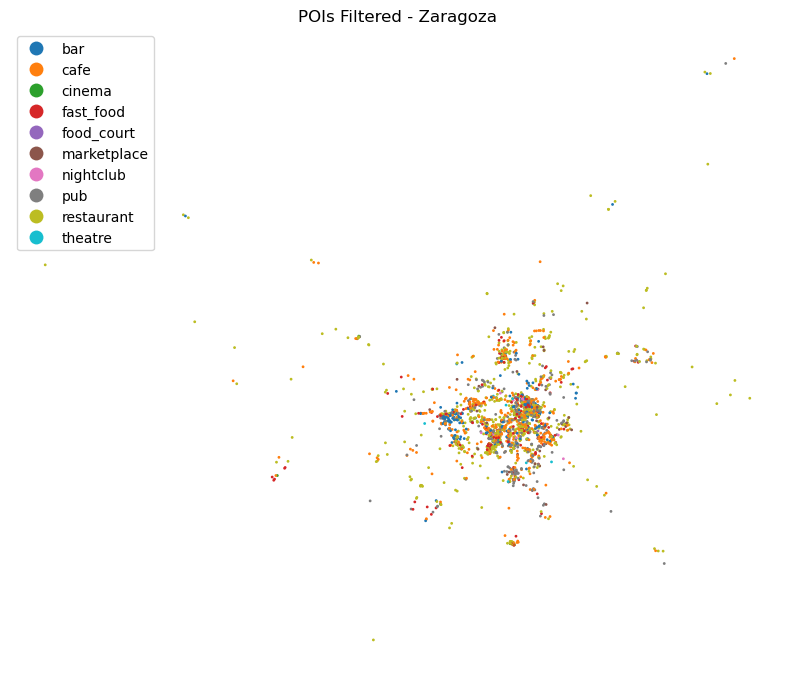

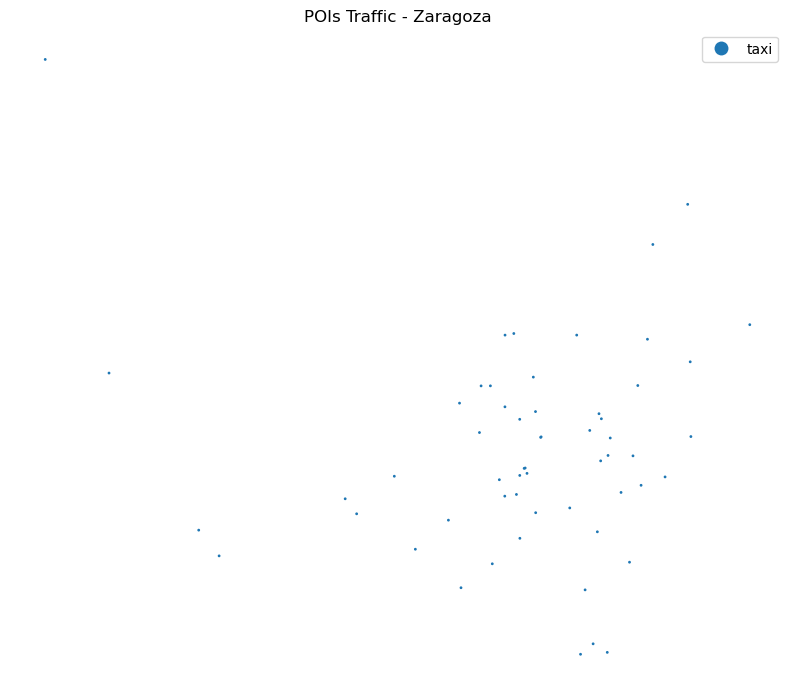

In [11]:
ax = pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Filtered - Zaragoza')
ax.set_axis_off()

ax = pois_traffic.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Traffic - Zaragoza')
ax.set_axis_off()

## Buffer streets by 50 m

In [12]:
buffered_50 = osm_roads.copy()
buffered_50['geometry'] = buffered_50.geometry.buffer(50)

## Count traffic signals per segment

In [13]:
signals_join = gpd.sjoin(signals, buffered_50, how="left", predicate="within")
signals_count = signals_join.groupby('index_right').size().rename('signal_count')

In [14]:
osm_roads_sig = osm_roads.join(signals_count)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].fillna(0) / osm_roads_sig['length']
q90 = osm_roads_sig['signal_count'].quantile(0.90)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].clip(upper=q90)
osm_roads_sig['signal_count'].describe()

count    14600.000000
mean         0.008967
std          0.020276
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.062375
Name: signal_count, dtype: float64

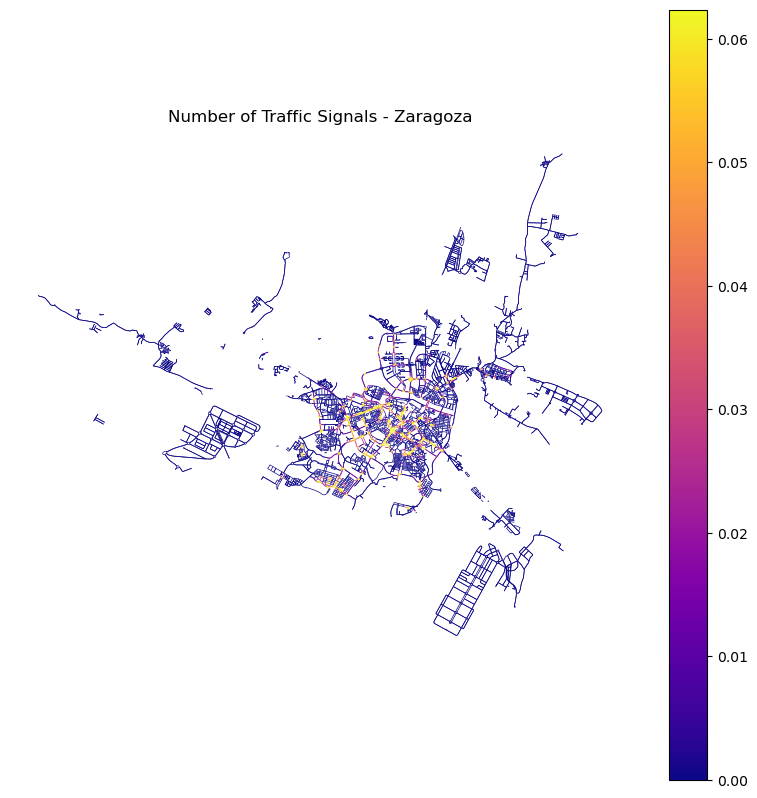

In [15]:
ax = osm_roads_sig.plot(column='signal_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Traffic Signals - Zaragoza')
ax.set_axis_off()

## Count transport stops per segment

In [16]:
transport_join = gpd.sjoin(transport, buffered_50, how="left", predicate="within")
transport_count = transport_join.groupby('index_right').size().rename('transport_count')

traffic_join = gpd.sjoin(pois_traffic, buffered_50, how="left", predicate="within")
traffic_count = traffic_join.groupby('index_right').size().rename('traffic_count')

In [17]:
osm_roads_transport = osm_roads.join(transport_count)
osm_roads_transport = osm_roads_transport.join(traffic_count)
osm_roads_transport['transport_count'] = (
    osm_roads_transport['transport_count'].fillna(0) +
    osm_roads_transport['traffic_count'].fillna(0)
) / osm_roads_transport['length']
q90 = osm_roads_transport['transport_count'].quantile(0.90)
osm_roads_transport['transport_count'] = osm_roads_transport['transport_count'].clip(upper=q90)

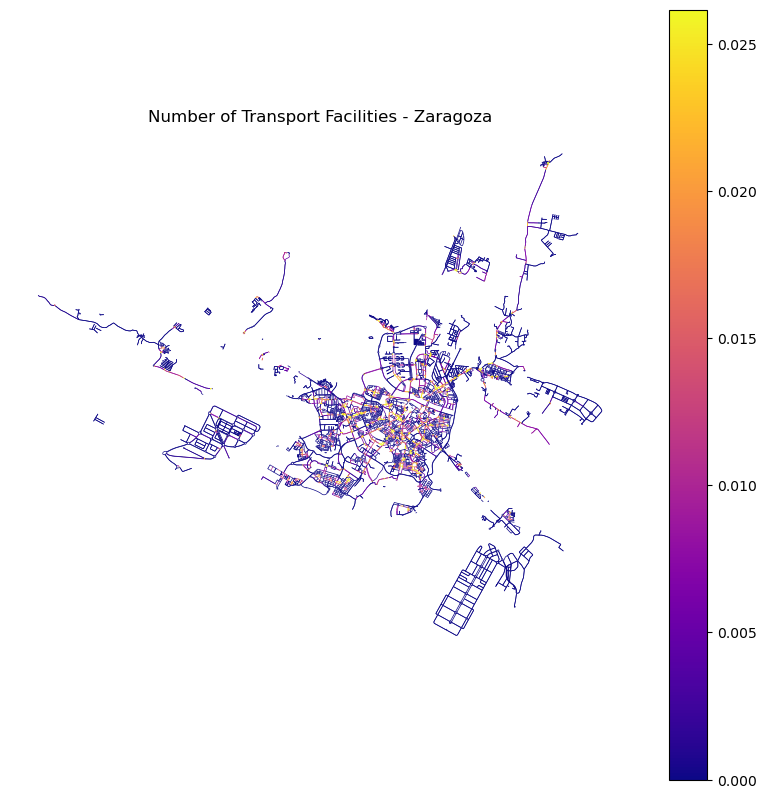

In [18]:
ax = osm_roads_transport.plot(column='transport_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Transport Facilities - Zaragoza')
ax.set_axis_off()

## Count POIs per segment

In [19]:
pois_join = gpd.sjoin(pois_filtered, buffered_50, how="left", predicate="within")
pois_count = pois_join.groupby('index_right').size().rename('pois_count')
pois_count

index_right
0.0         6
1.0        10
2.0         3
3.0         1
4.0         2
           ..
14594.0     1
14595.0     2
14597.0     1
14598.0     4
14599.0     1
Name: pois_count, Length: 3947, dtype: int64

In [20]:
osm_roads_pois = osm_roads.join(pois_count)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].fillna(0) / osm_roads_pois['length']
q99 = osm_roads_pois['pois_count'].quantile(0.99)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].clip(upper=q99)

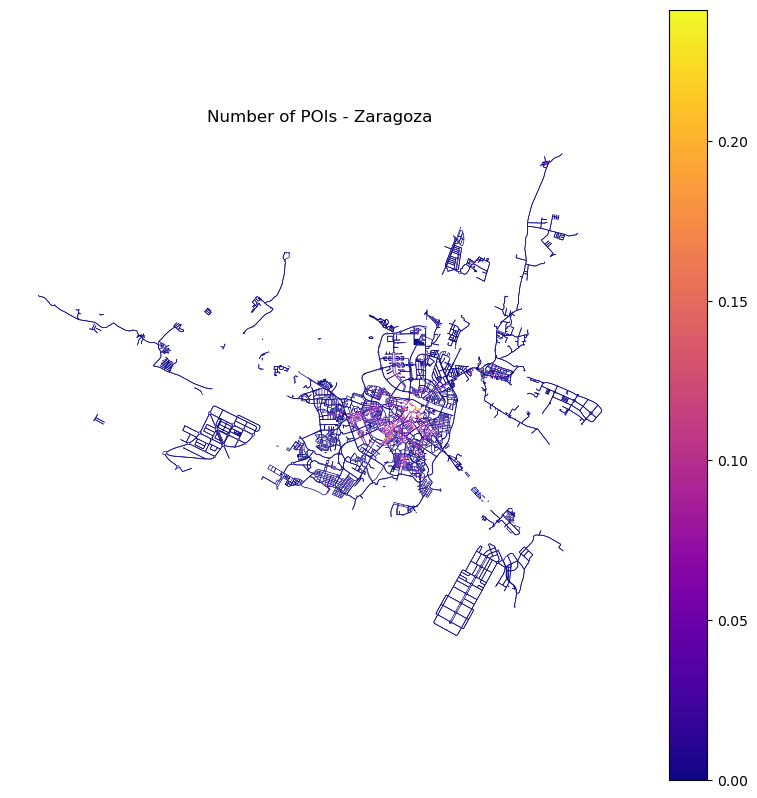

In [21]:
ax = osm_roads_pois.plot(column='pois_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of POIs - Zaragoza')
ax.set_axis_off()

## Merge and Export

In [22]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "signals": osm_roads_sig["signal_count"],
    "transport": osm_roads_transport["transport_count"],
    "pois": osm_roads_pois["pois_count"],
}).fillna(0)
dataset.head()

,road_id,signals,transport,pois
0.0,30389382_249502424_0,0.062375,0.000000,0.097381
1.0,30389382_30389461_0,0.062375,0.024000,0.120001
2.0,30389389_4398109455_0,0.031287,0.010429,0.015644
3.0,30389391_30575132_0,0.062375,0.000000,0.091570
4.0,30389400_3847861549_0,0.000000,0.026187,0.026569


In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

path = os.path.join(output_dir, "osm_points_features.csv")
dataset.to_csv(path, index=False)
print(f"Exported: {path}")

Exported: data\osm_points_features.csv
